# Day 25:  Understanding and Implementing Random Forests

---

## Objectives:

- Comprehend the fundamentals of **Random Forests**.
- Learn about **Ensemble Learning**.
- Implement a Random Forest from scratch.
- Apply the model to a real-world dataset.
- Utilize robust visualizations to interpret results.

---

## 1. Introduction to Random Forests

### 1.1 What is Ensemble Learning?

**Ensemble Learning** combines multiple models to improve performance over individual models. The main types are:

- **Bagging** (Bootstrap Aggregating): Averages predictions from multiple models trained on different subsets of data.
- **Boosting**: Sequentially trains models, each correcting errors from the previous ones.

### 1.2 What is a Random Forest?

A **Random Forest** is an ensemble method that combines multiple decision trees to enhance predictive accuracy and control overfitting. Each tree is trained on a random subset of data and features.

---

## 2. How Does Random Forest Work?

1. **Bootstrap Sampling**: Randomly sample data with replacement to create multiple subsets.
2. **Feature Randomness**: At each split, consider a random subset of features to reduce correlation among trees.
3. **Aggregation**:
   - **Classification**: Majority voting.
   - **Regression**: Averaging predictions.

---

## 3. Advantages of Random Forest

- **Robustness**: Handles noise and outliers effectively.
- **Feature Importance**: Provides insights into feature significance.
- **Versatility**: Applicable to both classification and regression tasks.

---

## 4. Dataset Overview

We'll use the **Wine Quality Dataset**, which includes:

- **Features**: Physicochemical properties of wine.
- **Target**: Quality rating (0-10).

---


## 5. Data Loading and Exploration

In [2]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Load the dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

In [4]:
#Display first few rows
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 6. EDA


In [5]:
#Summary statistics
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [6]:
#Check for missing values
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

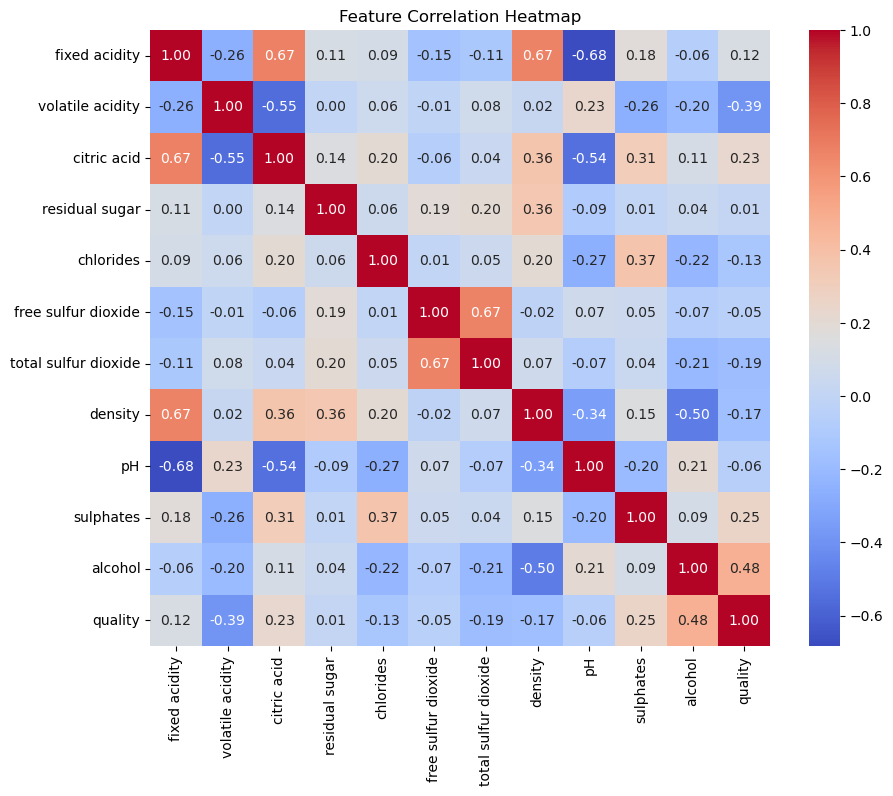

In [7]:
#Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## 7. Data Preprocessing

In [10]:
#Define feature variables (X) and target variable (y)
X = df.drop('quality', axis=1)
y = df['quality']

In [11]:
#Binarize the target variable
y = (y >=7).astype(int)

In [14]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

## 8. Implementing Random Forest


In [15]:
from collections import Counter
from sklearn.tree import DecisionTreeClassifier

In [22]:
class RandomForest:
    def __init__(self, n_trees=100, max_depth=None, min_samples_split=2, max_features='sqrt'):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []

    def bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, n_samples, replace=True)
        return X[indices], y[indices]

    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_trees):
            tree = DecisionTreeClassifier(
                max_depth = self.max_depth,
                min_samples_split = self.min_samples_split,
                max_features=self.max_features
            )
            X_sample, y_sample = self.bootstrap_sample(X,y)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        tree_preds = np.swapaxes(tree_preds, 0 , 1)
        y_pred = [Counter(tree_pred).most_common(1)[0][0] for tree_pred in tree_preds]
        return np.array(y_pred)

## 9. Training the Random Forest

In [23]:
#Initialize and train the Random Forest Model
rf_model = RandomForest(n_trees=100, max_depth=None, min_samples_split=2, max_features='sqrt')
rf_model.fit(X_train.values, y_train.values)

## 10. Model Evaluation

In [24]:
#Predict on the test set
y_pred = rf_model.predict(X_test.values)

In [25]:
#Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       273
           1       0.76      0.55      0.64        47

    accuracy                           0.91       320
   macro avg       0.85      0.76      0.80       320
weighted avg       0.90      0.91      0.90       320



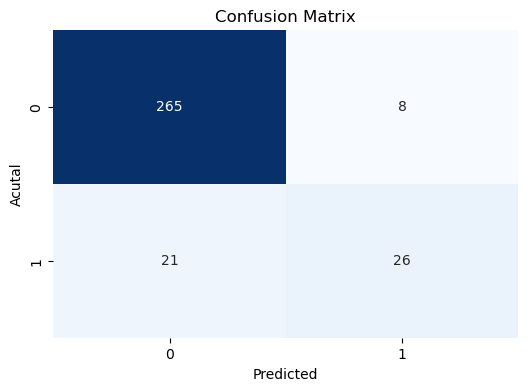

In [26]:
#Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Acutal')
plt.show()

In [28]:
# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.91


## 11. Feature Importance


In [29]:
#Calculate Feature Importance
importances = np.mean([tree.feature_importances_ for tree in rf_model.trees], axis=0)
feature_names = X.columns

In [30]:
#Create a DataFrame
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
featuer_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

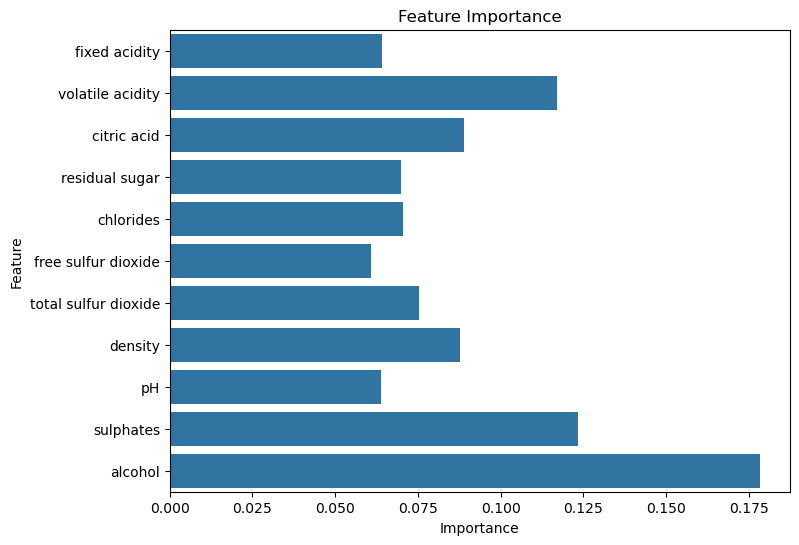

In [31]:
#Plot feature Importance
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance')
plt.show()

## 12. Confusion

In this notebook, we've:

- Explored the **Wine Quality Dataset**.
- Understood key concepts: **Ensemble Learning** and **Random Forests**.
- Implemented a Random Forest classifier from scratch.
- Evaluated the model using classification metrics and visualizations.
- Identified important features influencing wine quality.

Understanding Random Forests and their implementation enhances our ability to build robust and accurate machine learning models.